Epoch 0, Loss: 1.0156
Epoch 100, Loss: 0.9928
Epoch 200, Loss: 0.9735
Epoch 300, Loss: 0.9477
Epoch 400, Loss: 0.9125
Epoch 500, Loss: 0.8657
Epoch 600, Loss: 0.8057
Epoch 700, Loss: 0.7331
Epoch 800, Loss: 0.6510
Epoch 900, Loss: 0.5649
Epoch 1000, Loss: 0.4818
Epoch 1100, Loss: 0.4077
Epoch 1200, Loss: 0.3465
Epoch 1300, Loss: 0.2994
Epoch 1400, Loss: 0.2653
Epoch 1500, Loss: 0.2418
Epoch 1600, Loss: 0.2262
Epoch 1700, Loss: 0.2161
Epoch 1800, Loss: 0.2098
Epoch 1900, Loss: 0.2058


C:\Users\22826\AppData\Local\Temp\ipykernel_14520\3500540556.py:185: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEOGRAPH-4E07}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\22826\AppData\Local\Temp\ipykernel_14520\3500540556.py:185: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\magicpy3.13\xuexinew\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEOGRAPH-4E07}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\magicpy3.13\xuexinew\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


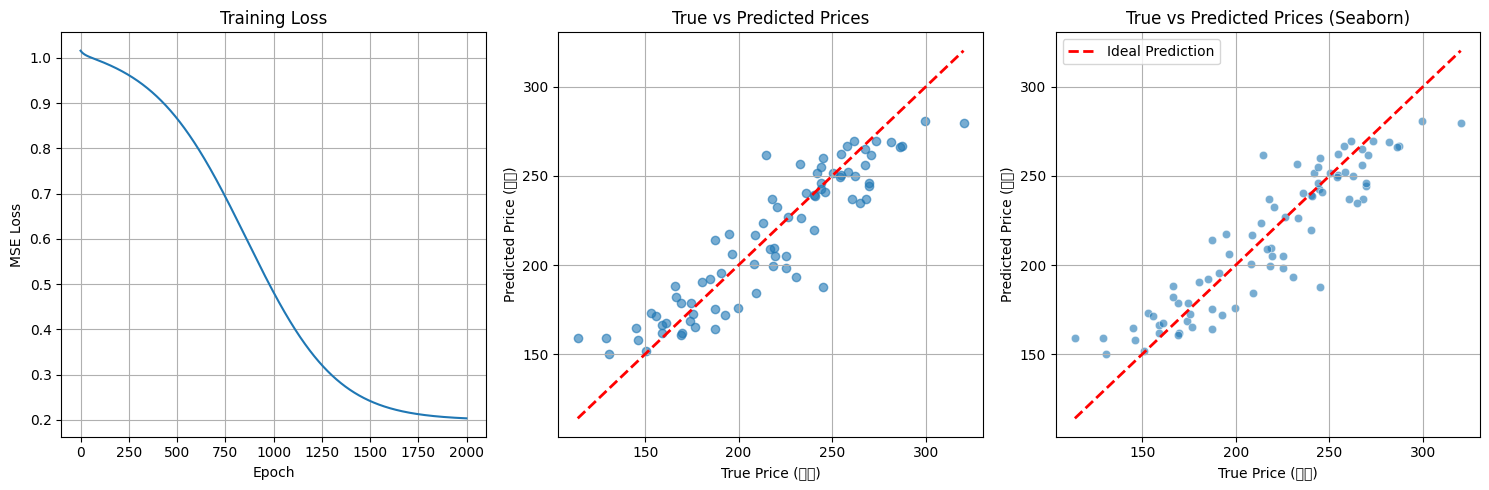


模型评估指标:
均方误差 (MSE): 347.71
均方根误差 (RMSE): 18.65
平均绝对误差 (MAE): 14.74
决定系数 (R²): 0.8271

前10个测试样本的预测结果:
   True_Price  Predicted_Price  Absolute_Error
0  260.415705       237.111382       23.304323
1  245.070071       187.910467       57.159604
2  219.203298       204.809751       14.393547
3  208.153520       200.418336        7.735184
4  244.247187       242.854229        1.392957
5  261.467135       269.534102        8.066967
6  240.479843       239.192473        1.287369
7  208.519133       216.891857        8.372724
8  226.150825       226.752183        0.601358
9  209.280111       184.228747       25.051364


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子
np.random.seed(42)

# 生成200个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})

# 定义Sigmoid激活函数及其导数
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))  # 防止溢出

def sigmoid_derivative(x):
    return x * (1 - x)

class BPNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        # 初始化权重和偏置
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.1
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.1
        self.bias_hidden = np.zeros((1, hidden_size))
        self.bias_output = np.zeros((1, output_size))
        self.learning_rate = learning_rate
        
    def forward(self, X):
        # 前向传播
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = sigmoid(self.hidden_input)
        self.final_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        # 输出层使用线性激活函数（回归问题）
        self.final_output = self.final_input
        return self.final_output
    
    def backward(self, X, y, output):
        # 反向传播
        m = X.shape[0]
        
        # 计算输出层误差
        output_error = output - y
        d_output = output_error / m  # 对于线性输出，导数为1
        
        # 隐藏层误差
        hidden_error = np.dot(d_output, self.weights_hidden_output.T)
        d_hidden = hidden_error * sigmoid_derivative(self.hidden_output)
        
        # 更新权重和偏置
        self.weights_hidden_output -= self.learning_rate * np.dot(self.hidden_output.T, d_output)
        self.weights_input_hidden -= self.learning_rate * np.dot(X.T, d_hidden)
        self.bias_output -= self.learning_rate * np.sum(d_output, axis=0, keepdims=True)
        self.bias_hidden -= self.learning_rate * np.sum(d_hidden, axis=0, keepdims=True)
    
    def train(self, X, y, epochs=1000):
        losses = []
        for epoch in range(epochs):
            # 前向传播
            output = self.forward(X)
            
            # 计算损失（均方误差）
            loss = np.mean((output - y) ** 2)
            losses.append(loss)
            
            # 反向传播
            self.backward(X, y, output)
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        
        return losses
    
    def predict(self, X):
        return self.forward(X)

# 数据预处理
# 选择特征和目标变量
X = data[['area', 'bedrooms', 'age', 'location']].values
y = data['price'].values.reshape(-1, 1)

# 数据标准化
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_normalized = (X - X_mean) / X_std

y_mean = np.mean(y, axis=0)
y_std = np.std(y, axis=0)
y_normalized = (y - y_mean) / y_std

# 划分训练集和测试集 (80% 训练, 20% 测试)
split_ratio = 0.8
split_index = int(n_samples * split_ratio)

X_train = X_normalized[:split_index]
X_test = X_normalized[split_index:]
y_train = y_normalized[:split_index]
y_test = y_normalized[split_index:]

# 创建并训练神经网络
input_size = 4
hidden_size = 8
output_size = 1
learning_rate = 0.01
epochs = 2000

nn = BPNeuralNetwork(input_size, hidden_size, output_size, learning_rate)
losses = nn.train(X_train, y_train, epochs)

# 预测
y_pred_normalized = nn.predict(X_test)
# 反标准化预测结果
y_pred = y_pred_normalized * y_std + y_mean

# 反标准化真实值用于比较
y_test_original = y_test * y_std + y_mean

# 可视化结果
plt.figure(figsize=(15, 5))

# 1. 损失曲线
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)

# 2. 预测 vs 真实值散点图
plt.subplot(1, 3, 2)
plt.scatter(y_test_original, y_pred, alpha=0.6)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
plt.xlabel('True Price (万元)')
plt.ylabel('Predicted Price (万元)')
plt.title('True vs Predicted Prices')
plt.grid(True)

# 3. 使用seaborn绘制更美观的散点图
plt.subplot(1, 3, 3)
# 创建包含真实值和预测值的DataFrame
results_df = pd.DataFrame({
    'True_Price': y_test_original.flatten(),
    'Predicted_Price': y_pred.flatten()
})
sns.scatterplot(data=results_df, x='True_Price', y='Predicted_Price', alpha=0.6)
# 添加理想预测线
min_val = min(results_df['True_Price'].min(), results_df['Predicted_Price'].min())
max_val = max(results_df['True_Price'].max(), results_df['Predicted_Price'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Prediction')
plt.xlabel('True Price (万元)')
plt.ylabel('Predicted Price (万元)')
plt.title('True vs Predicted Prices (Seaborn)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 计算评估指标
mse = np.mean((y_pred - y_test_original) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_pred - y_test_original))
r2 = 1 - np.sum((y_test_original - y_pred) ** 2) / np.sum((y_test_original - np.mean(y_test_original)) ** 2)

print(f"\n模型评估指标:")
print(f"均方误差 (MSE): {mse:.2f}")
print(f"均方根误差 (RMSE): {rmse:.2f}")
print(f"平均绝对误差 (MAE): {mae:.2f}")
print(f"决定系数 (R²): {r2:.4f}")

# 显示前10个测试样本的预测结果
print(f"\n前10个测试样本的预测结果:")
comparison = pd.DataFrame({
    'True_Price': y_test_original.flatten()[:10],
    'Predicted_Price': y_pred.flatten()[:10],
    'Absolute_Error': np.abs(y_test_original.flatten()[:10] - y_pred.flatten()[:10])
})
print(comparison)